In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm

In [ ]:
!pip install transformers

In [ ]:
!pip install lightgbm

In [ ]:
import pandas as pd
import numpy as np
import re
import time
import timeit
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,accuracy_score,f1_score,roc_auc_score, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PhiUSIIL_Phishing_URL_Dataset.csv to PhiUSIIL_Phishing_URL_Dataset (3).csv


In [ ]:
df = pd.read_csv('/content/PhiUSIIL_Phishing_URL_Dataset.csv')

df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [ ]:
df.shape
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [ ]:
def extract_features(url):

    features = []

    features.append(len(url))

    features.append(url.count('.'))
    features.append(url.count('-'))
    features.append(len(re.findall('[^a-zA-Z0-9]', url)))
    features.append(sum(c.isdigit() for c in url))

    features.append(len(url.split('.')))

    features.append(1 if 'https' in url else 0)

    features.append(1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0)

    return features

In [ ]:
print(df.columns)
df.head()

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [ ]:
features = df['URL'].apply(lambda x: extract_features(x))

features = pd.DataFrame(features.tolist())

In [ ]:
tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2,4),
    max_features=5000
)

X_tfidf = tfidf.fit_transform(df['URL'])

In [ ]:
from scipy.sparse import hstack

X = hstack([features, X_tfidf])

y = df['label']

In [ ]:
df = df.dropna()

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 107815, number of negative: 80821
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 12.651896 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1029629
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 5008
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571550 -> initscore=0.288180
[LightGBM] [Info] Start training from score 0.288180


LGBMClassifier(random_state=42)

In [ ]:
print(y_train.isna().sum())

0


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1
)

model.fit(X_train,y_train)

RandomForestClassifier(max_depth=20, n_jobs=-1)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9959498717105961
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20124
           1       0.99      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



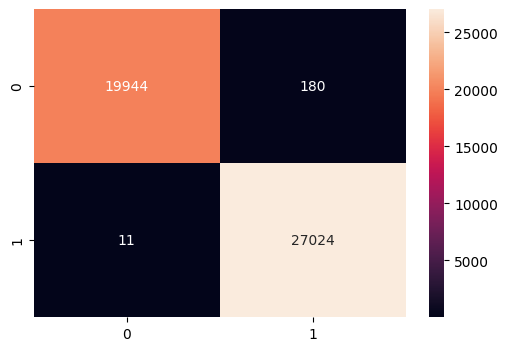

In [ ]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
def predict_url(url):

    f = extract_features(url)
    f = np.array(f).reshape(1,-1)

    t = tfidf.transform([url])

    final = hstack([f,t])

    pred = model.predict(final)

    if pred[0] == 1:
        print("⚠️ Phishing URL Detected")
    else:
        print("✅ Legitimate URL")

In [ ]:
predict_url("http://paypal-login-security-update.com")
predict_url("https://google.com")

✅ Legitimate URL
✅ Legitimate URL


In [ ]:
joblib.dump(model,'phishing_model.pkl')
joblib.dump(tfidf,'tfidf.pkl')

['tfidf.pkl']

In [ ]:
model = joblib.load('phishing_model.pkl')
tfidf = joblib.load('tfidf.pkl')

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc)
f1 = f1_score(y_test, y_pred)
print("F1 Score (Phishing):", f1)

Accuracy: 0.9959498717105961

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     20124
           1       0.99      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

AUC-ROC: 0.9988604267376187
F1 Score (Phishing): 0.9964785486458083


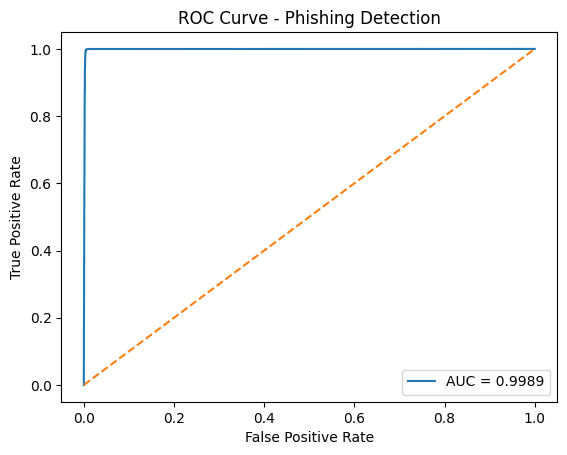

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Phishing Detection")
plt.legend(loc="lower right")

plt.show()

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

fpr = fp / (fp + tn)
print("False Positive Rate:", fpr)

False Positive Rate: 0.008944543828264758


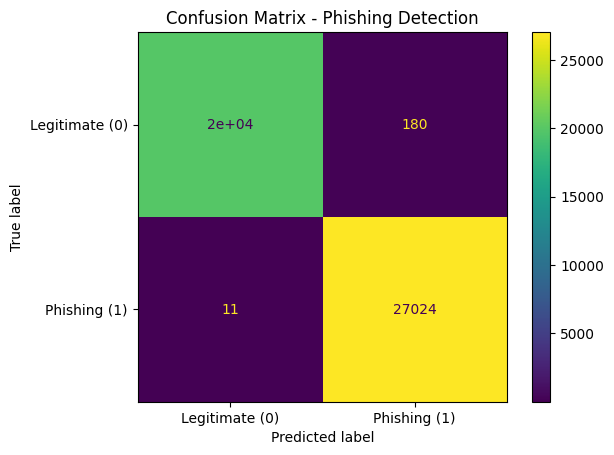

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate (0)", "Phishing (1)"])

disp.plot()
plt.title("Confusion Matrix - Phishing Detection")
plt.show()

In [ ]:
latency = timeit.timeit(lambda: model.predict(X_test), number=10)
latency = (latency / 10) / X_test.shape[0] * 1000

print("Average Inference Latency (ms):", latency)

Average Inference Latency (ms): 0.024484154683092056


In [ ]:
runs = 10

total_time = timeit.timeit(lambda: model.predict(X_test), number=runs)

avg_latency = (total_time / runs) / X_test.shape[0] * 1000

print("Average Inference Latency (ms per URL):", avg_latency)

Average Inference Latency (ms per URL): 0.023979322023367482


In [ ]:
sample = X_test[0]

start = time.time()
model.predict(sample)
end = time.time()

latency_single = (end - start) * 1000

print("Single URL Latency (ms):", latency_single)

Single URL Latency (ms): 40.341854095458984


In [ ]:
def predict_url(features_vector):
    prob = model.predict_proba([features_vector])[0][1]
    label = 1 if prob > 0.5 else 0
    return label, prob